# Stat Arb in Crypto


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from data_loader import load_universe, get_returns, UNIVERSE
from signals import (tsmom, xsmom, mean_reversion, normalize_signal, combine_signals, 
                     smooth_signal, short_term_reversal, vol_adjusted_momentum)
from optimization import compute_optimal_weights
from backtest import Backtester, get_stats, print_stats, calc_drawdown_series

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
%load_ext autoreload
%autoreload 2

## Data Loading


In [3]:
# load hourly prices (will cache after first fetch)
px = load_universe(UNIVERSE, start='2022-01-01', refresh=False)
ret = get_returns(px)

print(f"Data shape: {px.shape}")
print(f"Date range: {px.index[0]} to {px.index[-1]}")
px.tail()


loading cached data from /Users/euler/Desktop/GT/Quant/Projects/StatArbParentDir/stat-arb-research/data/universe_BTCUSDT_ETHUSDT_SOLUSDT_etc.parquet
Data shape: (35142, 16)
Date range: 2022-01-01 00:00:00 to 2026-01-04 05:00:00


,BTCUSDT,ETHUSDT,SOLUSDT,BNBUSDT,XRPUSDT,ADAUSDT,DOGEUSDT,AVAXUSDT,TRXUSDT,DOTUSDT,LINKUSDT,MATICUSDT,LTCUSDT,BCHUSDT,ATOMUSDT,UNIUSDT
2026-01-04 01:00:00,91235.37,3150.17,133.96,882.54,2.0353,0.3942,0.14653,13.96,0.2954,2.128,13.36,0.3794,82.28,644.8,2.253,5.969
2026-01-04 02:00:00,91124.00,3141.12,133.73,880.69,2.0311,0.3938,0.14716,13.92,0.2953,2.126,13.32,0.3794,82.19,644.1,2.244,5.936
2026-01-04 03:00:00,91236.78,3147.36,134.62,883.14,2.0581,0.3995,0.15102,14.01,0.2949,2.130,13.36,0.3794,82.54,646.3,2.255,5.942
2026-01-04 04:00:00,91408.00,3148.39,134.31,888.81,2.0610,0.3978,0.15207,14.00,0.2944,2.135,13.37,0.3794,82.44,648.9,2.250,5.919
2026-01-04 05:00:00,91408.00,3148.39,134.31,888.80,2.0618,0.3978,0.15182,14.01,0.2945,2.137,13.36,0.3794,82.41,649.9,2.252,5.916


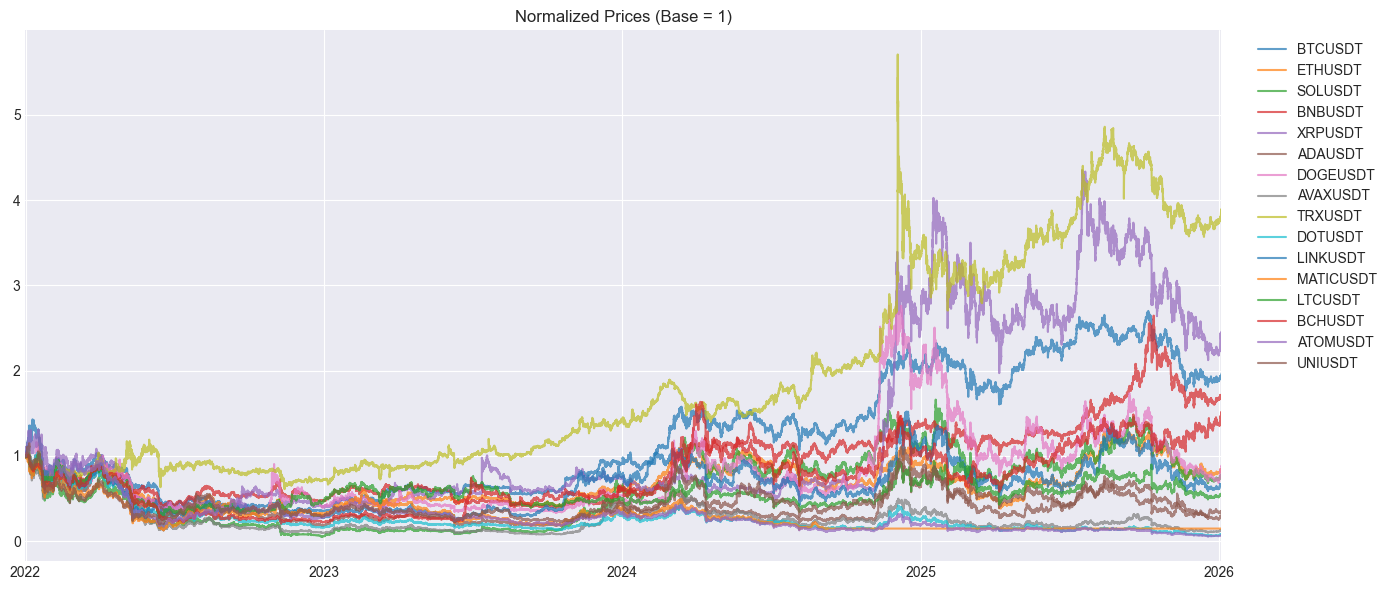

In [4]:
# quick look at cumulative returns
fig, ax = plt.subplots(figsize=(14, 6))
(px / px.iloc[0]).plot(ax=ax, alpha=0.7) #! alpha is transparency lol; for overlay
ax.set_title('Normalized Prices (Base = 1)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()


## Signal Generation


In [5]:
# params for signals - tuned for crypto markets
TSMOM_LOOKBACK = 336       # 14 days - long-term trend
XSMOM_LOOKBACK = 168       # 7 days - relative strength
VOLMOM_LOOKBACK = 336      # 14 days - vol-adjusted momentum
VOLMOM_VOL_LB = 168        # 7 days - volatility estimation
REVERSAL_LOOKBACK = 24     # 1 day - SHORT-term reversal (not long-term mean reversion)
SIGNAL_SMOOTH_HALFLIFE = 72  # 3-day EMA halflife (longer = more stable)

# compute raw signals
sig_tsmom = tsmom(px, TSMOM_LOOKBACK)
sig_xsmom = xsmom(ret, XSMOM_LOOKBACK)
sig_volmom = vol_adjusted_momentum(ret, VOLMOM_LOOKBACK, VOLMOM_VOL_LB)
sig_reversal = short_term_reversal(ret, REVERSAL_LOOKBACK)

# normalize each signal (dollar neutral, fully invested)
sig_tsmom_norm = normalize_signal(sig_tsmom)
sig_xsmom_norm = normalize_signal(sig_xsmom)
sig_volmom_norm = normalize_signal(sig_volmom)
sig_reversal_norm = normalize_signal(sig_reversal)

# apply EMA smoothing to reduce signal noise and turnover
sig_tsmom_norm = normalize_signal(smooth_signal(sig_tsmom_norm, SIGNAL_SMOOTH_HALFLIFE))
sig_xsmom_norm = normalize_signal(smooth_signal(sig_xsmom_norm, SIGNAL_SMOOTH_HALFLIFE))
sig_volmom_norm = normalize_signal(smooth_signal(sig_volmom_norm, SIGNAL_SMOOTH_HALFLIFE))
sig_reversal_norm = normalize_signal(smooth_signal(sig_reversal_norm, SIGNAL_SMOOTH_HALFLIFE))

In [6]:
print("Signal shapes:")
print(f"\tTSMOM: {sig_tsmom_norm.shape}")
print(f"\tXSMOM: {sig_xsmom_norm.shape}")
print(f"\tVolMom: {sig_volmom_norm.shape}")
print(f"\tReversal: {sig_reversal_norm.shape}")

Signal shapes:
	TSMOM: (35142, 16)
	XSMOM: (35142, 16)
	VolMom: (35142, 16)
	Reversal: (35142, 16)


In [11]:
combined_signal = combine_signals(signals=[sig_tsmom_norm, sig_xsmom_norm, sig_volmom_norm, sig_reversal_norm], weights=[0.34, 0.33, 0.33, 0.00])
combined_signal = normalize_signal(combined_signal)

In [ ]:
# # combine signals - weight momentum higher than reversal
# # momentum signals work better in crypto, reversal is more of a diversifier
# combined_signal = combine_signals([sig_tsmom_norm, sig_xsmom_norm, sig_volmom_norm, sig_reversal_norm], weights=[0.34, 0.33, 0.33, 0.00])  # 85% momentum, 15% reversal
# # re-normalize combined signal
# combined_signal = normalize_signal(combined_signal)

In [10]:
print(combined_signal)

NameError: name 'combined_signal' is not defined

In [12]:
print("Combined signal check:")
print(f"\tSum of abs weights: {combined_signal.abs().sum(axis=1).mean():.4f} (should be ~1)")
print(f"\tSum of weights: {combined_signal.sum(axis=1).mean():.6f} (should be ~0)")

Combined signal check:
	Sum of abs weights: 0.9999 (should be ~1)
	Sum of weights: -0.000000 (should be ~0)


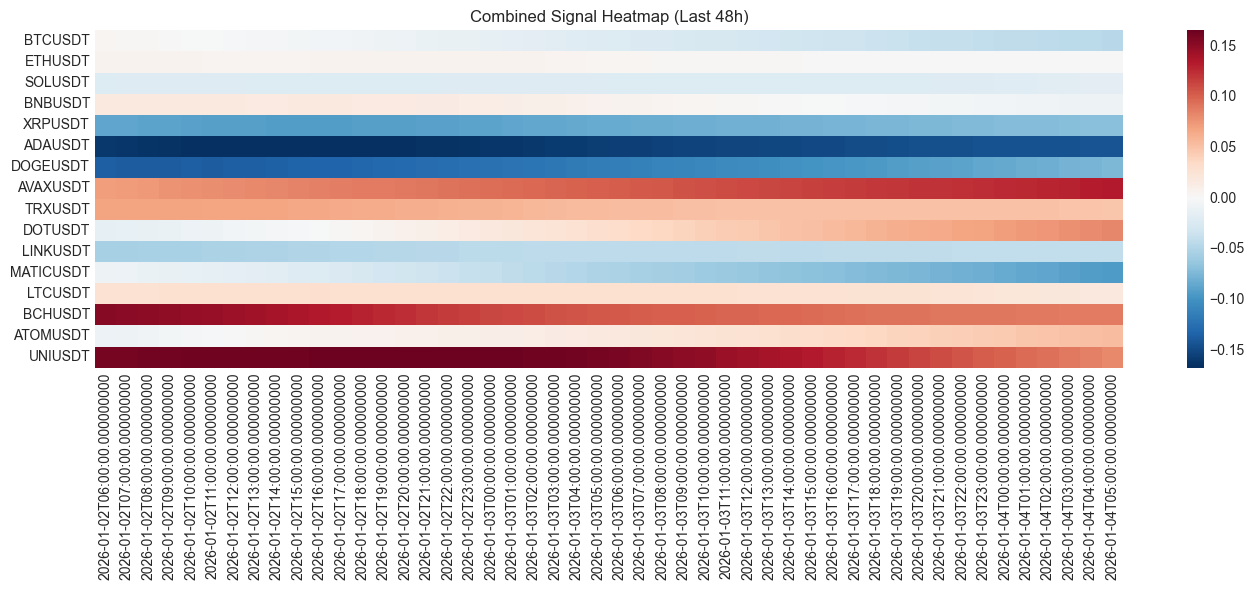

In [13]:
# viz: signal heatmap for last 48 hours
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(combined_signal.tail(48).T, cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Combined Signal Heatmap (Last 48h)')
plt.tight_layout()


## Portfolio Optimization


In [14]:
# compute optimal weights using general weighting scheme
# sigma^-1 * mu with vol targeting + weight smoothing

COV_WINDOW = 720    # 30 days in hours
SHRINKAGE = 0.20    # slightly more shrinkage for stability
TARGET_VOL = 0.15   # 15% annualized (more conservative)
MAX_LEVERAGE = 2.5  # cap leverage lower
WEIGHT_SMOOTH = 0.08  # slightly faster adaptation (signals are more stable now)

# this takes a minute...
print("Computing optimal weights (this may take a bit)...")
opt_weights = compute_optimal_weights(
    ret, 
    combined_signal,
    cov_window=COV_WINDOW,
    shrinkage=SHRINKAGE,
    target_vol=TARGET_VOL,
    max_leverage=MAX_LEVERAGE,
    weight_smooth=WEIGHT_SMOOTH
)


Computing optimal weights (this may take a bit)...


In [15]:
print(f"Weights shape: {opt_weights.shape}")
opt_weights.tail()

Weights shape: (34422, 16)


,BTCUSDT,ETHUSDT,SOLUSDT,BNBUSDT,XRPUSDT,ADAUSDT,DOGEUSDT,AVAXUSDT,TRXUSDT,DOTUSDT,LINKUSDT,MATICUSDT,LTCUSDT,BCHUSDT,ATOMUSDT,UNIUSDT
2026-01-04 01:00:00,-0.091143,0.011017,-0.012774,-0.003242,-0.110400,-0.116696,-0.098334,0.090297,0.265887,0.019565,-0.059038,-0.014953,0.032450,0.031044,0.010864,0.045457
2026-01-04 02:00:00,-0.094636,0.011404,-0.012576,-0.004772,-0.110222,-0.117561,-0.096907,0.091874,0.267359,0.021169,-0.059295,-0.014906,0.031877,0.030799,0.011850,0.044544
2026-01-04 03:00:00,-0.098194,0.011829,-0.012344,-0.006350,-0.110074,-0.118496,-0.095449,0.093519,0.268781,0.022852,-0.059597,-0.014853,0.031280,0.030605,0.012893,0.043597
2026-01-04 04:00:00,-0.102025,0.012151,-0.012122,-0.007909,-0.109762,-0.119464,-0.093601,0.095282,0.270080,0.024530,-0.060032,-0.014794,0.030606,0.030484,0.013991,0.042585
2026-01-04 05:00:00,-0.105818,0.012421,-0.011922,-0.009427,-0.109393,-0.120484,-0.091698,0.097020,0.271315,0.026292,-0.060508,-0.014737,0.029830,0.030434,0.015149,0.041525


In [16]:
opt_weights.abs().sum(axis=1).max()

np.float64(2.3482170007341256)

In [17]:
opt_weights.sum(axis=1).max() #! fixed

np.float64(3.608224830031759e-16)

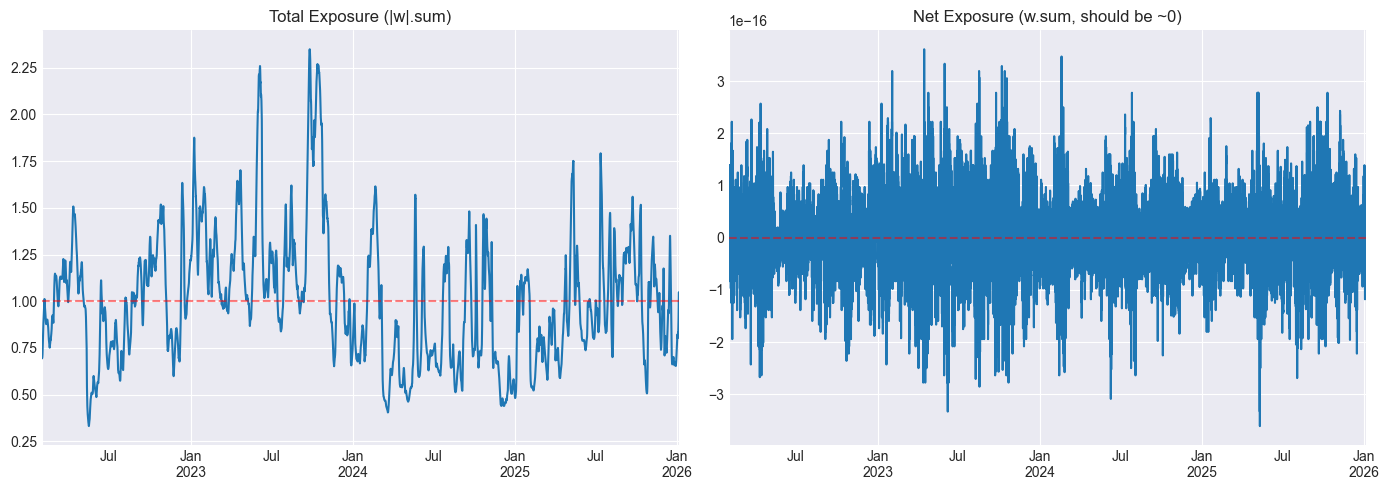

In [18]:
# check weight distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# abs sum of weights over time
opt_weights.abs().sum(axis=1).plot(ax=axes[0])
axes[0].set_title('Total Exposure (|w|.sum)')
axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.5)

# sum of weights (should be ~0 for dollar neutral)
opt_weights.sum(axis=1).plot(ax=axes[1])
axes[1].set_title('Net Exposure (w.sum, should be ~0)')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()


## Backtest


In [19]:
# run backtest
TCOST_BPS = 5  # 5 bps per trade

bt = Backtester(ret, opt_weights, tcost_bps=TCOST_BPS)
results = bt.run()

# print performance
print_stats(results['net_ret'], 'Stat Arb Strategy (Net)')
print_stats(results['gross_ret'], 'Stat Arb Strategy (Gross)')

print(f"\nAvg Daily Turnover: {results['turnover'].mean():.2%}")
print(f"Avg Hourly Tcost: {results['tcost'].mean()*1e4:.2f} bps")



Stat Arb Strategy (Net) Performance:
  Sharpe:     0.87
  Sortino:    1.24
  Ann Return: 15.2%
  Ann Vol:    17.4%
  Max DD:     -22.2%
  Total Ret:  71.2%

Stat Arb Strategy (Gross) Performance:
  Sharpe:     1.06
  Sortino:    1.50
  Ann Return: 18.4%
  Ann Vol:    17.4%
  Max DD:     -20.6%
  Total Ret:  94.2%

Avg Daily Turnover: 0.73%
Avg Hourly Tcost: 0.04 bps


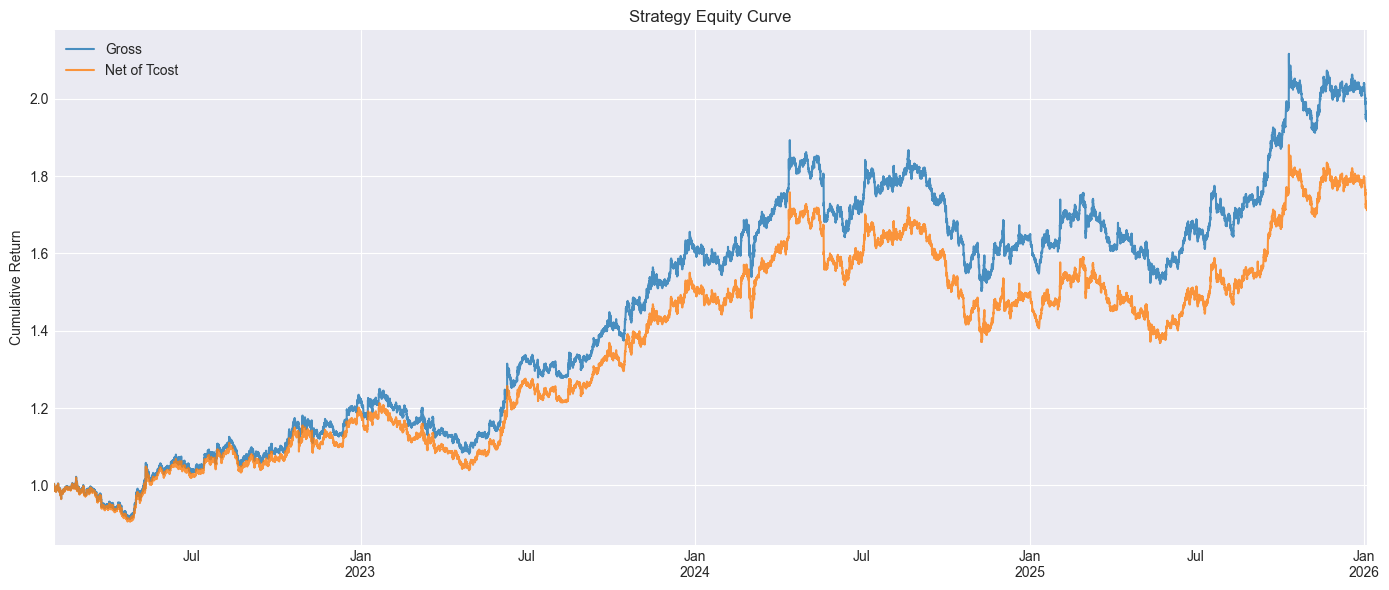

In [20]:
# equity curve
equity_net = bt.get_equity_curve(use_net=True)
equity_gross = bt.get_equity_curve(use_net=False)

fig, ax = plt.subplots(figsize=(14, 6))
equity_gross.plot(ax=ax, label='Gross', alpha=0.8)
equity_net.plot(ax=ax, label='Net of Tcost', alpha=0.8)
ax.set_title('Strategy Equity Curve')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.tight_layout()


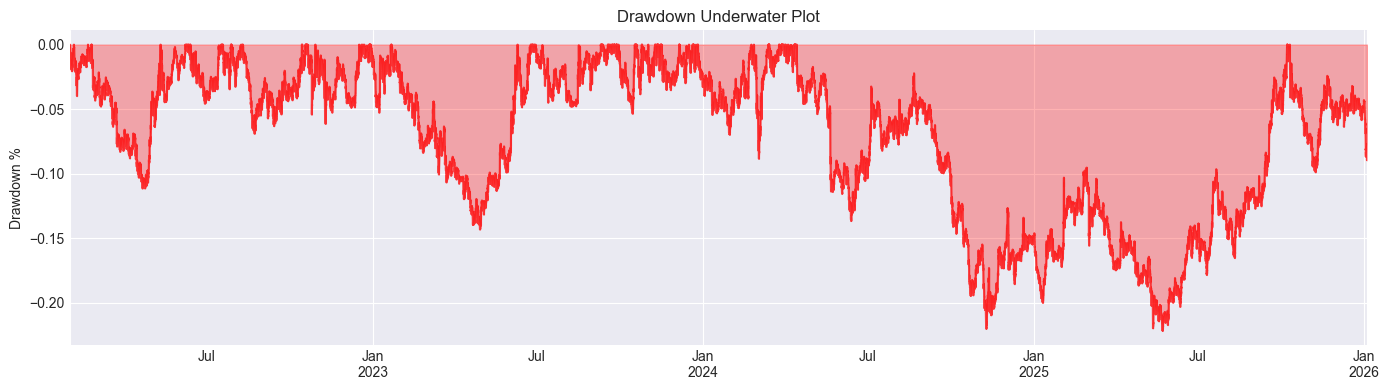

In [21]:
# drawdown underwater plot
dd = calc_drawdown_series(equity_net)

fig, ax = plt.subplots(figsize=(14, 4))
dd.plot(ax=ax, color='red', alpha=0.7)
ax.fill_between(dd.index, dd.values, 0, color='red', alpha=0.3)
ax.set_title('Drawdown Underwater Plot')
ax.set_ylabel('Drawdown %')
plt.tight_layout()


## Benchmark Comparison


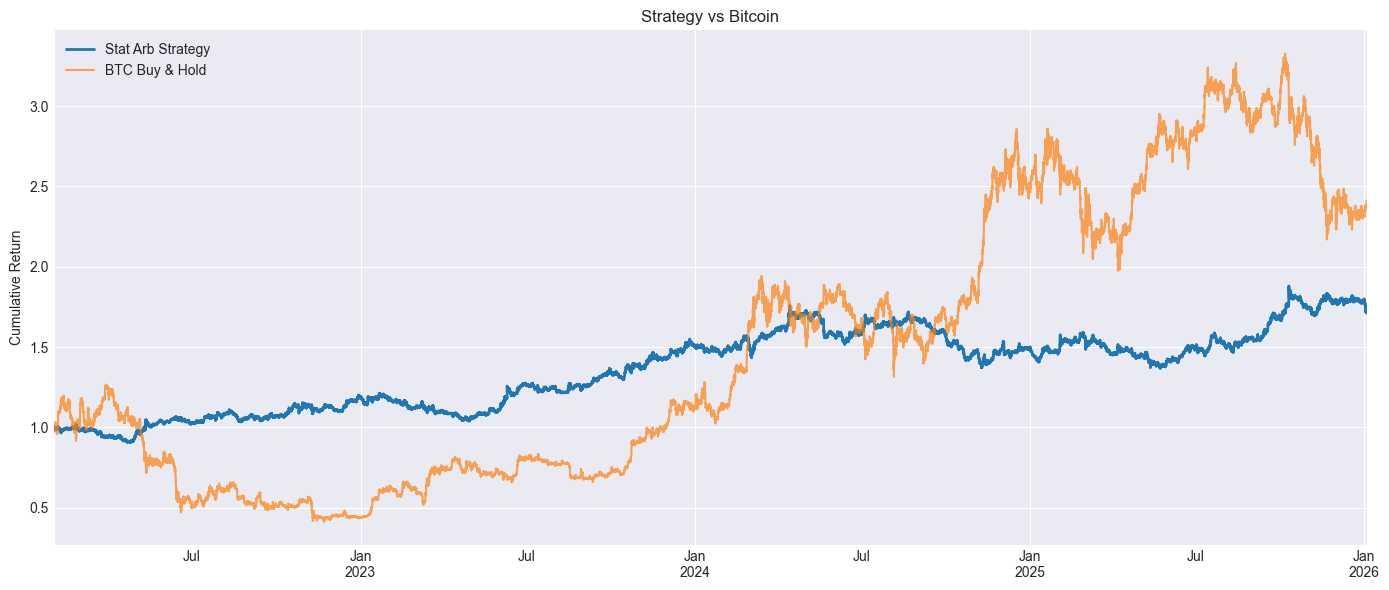

In [22]:
# compare to BTC buy-and-hold
btc_ret = ret['BTCUSDT'].loc[results['net_ret'].index]
btc_equity = (1 + btc_ret).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
equity_net.plot(ax=ax, label='Stat Arb Strategy', linewidth=2)
btc_equity.plot(ax=ax, label='BTC Buy & Hold', alpha=0.7)
ax.set_title('Strategy vs Bitcoin')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.tight_layout()


In [23]:
# BTC stats for comparison
print_stats(btc_ret, 'BTC Buy & Hold')



BTC Buy & Hold Performance:
  Sharpe:     0.69
  Sortino:    0.88
  Ann Return: 35.4%
  Ann Vol:    51.0%
  Max DD:     -67.4%
  Total Ret:  141.3%


## Alpha/Beta Purification Regression


In [24]:
# regress strategy returns on BTC to separate alpha from beta
#! strat_ret = alpha + beta * btc_ret + epsilon; alpha contribution --> alpha + residual; beta contribution --> beta * btc_ret
#! mean of alpha contribution --> alpha; mean of beta contribution --> beta * mean(btc_ret)

strat_ret = results['net_ret'].dropna()
btc_ret_aligned = btc_ret.loc[strat_ret.index].dropna()

# align
common = strat_ret.index.intersection(btc_ret_aligned.index)
Y = strat_ret.loc[common]
X = btc_ret_aligned.loc[common]

# add constant for alpha (intercept, 1s)
X_const = sm.add_constant(X)

# fit OLS
model = sm.OLS(Y, X_const).fit()


In [36]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     476.9
Date:                Sat, 10 Jan 2026   Prob (F-statistic):          5.32e-105
Time:                        14:29:21   Log-Likelihood:             1.6787e+05
No. Observations:               34422   AIC:                        -3.357e+05
Df Residuals:                   34420   BIC:                        -3.357e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.896e-05   9.94e-06      1.907      0.0

In [26]:
# extract alpha and beta
alpha = model.params['const']
beta = model.params['BTCUSDT']

print(f"\nAlpha (hourly): {alpha:.6f}")
print(f"Alpha (annualized): {alpha * 24 * 365 * 100:.2f}%")
print(f"Alpha t-stat: {model.tvalues['const']:.2f}")
print(f"\nBeta: {beta:.4f}")
print(f"Beta t-stat: {model.tvalues['BTCUSDT']:.2f}")



Alpha (hourly): 0.000019
Alpha (annualized): 16.61%
Alpha t-stat: 1.91

Beta: -0.0398
Beta t-stat: -21.84


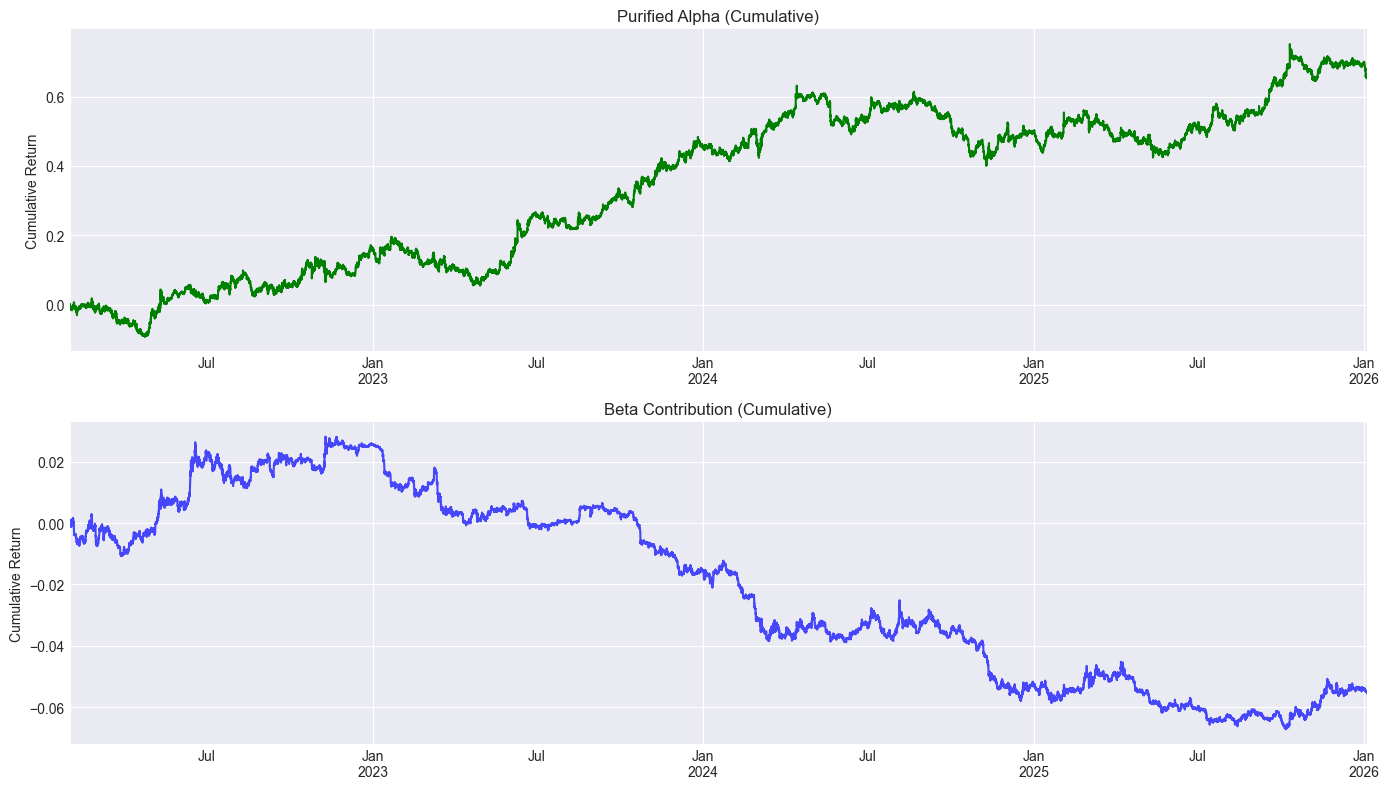

In [27]:
# compute purified alpha (residual from regression)
alpha_contribution = model.params['const'] + model.resid
beta_contribution = model.params['BTCUSDT'] * X

# plot purified alpha
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

alpha_contribution.cumsum().plot(ax=axes[0], color='green')
axes[0].set_title('Purified Alpha (Cumulative)')
axes[0].set_ylabel('Cumulative Return')

beta_contribution.cumsum().plot(ax=axes[1], color='blue', alpha=0.7)
axes[1].set_title('Beta Contribution (Cumulative)')
axes[1].set_ylabel('Cumulative Return')

plt.tight_layout()


In [28]:
# information ratio of purified alpha
ir = alpha_contribution.mean() / alpha_contribution.std() * np.sqrt(24*365)
print(f"Information Ratio (Purified Alpha): {ir:.2f}")

Information Ratio (Purified Alpha): 0.96


In [29]:
# verify alpha is uncorrelated to market
corr = alpha_contribution.corr(X)
print(f"Correlation of Alpha to BTC: {corr:.4f} (should be ~0)")

Correlation of Alpha to BTC: -0.0000 (should be ~0)


## 7. Individual Signal Analysis


In [30]:
#! backtesting each signal individually to see contribution

def quick_backtest(signal, ret, name):
    """run a quick backtest on a normalized signal"""
    bt = Backtester(ret, signal, tcost_bps=5)
    res = bt.run()
    stats = get_stats(res['net_ret'])
    return stats

# individual signal backtests
stats_tsmom = quick_backtest(sig_tsmom_norm, ret, 'TSMOM')
stats_xsmom = quick_backtest(sig_xsmom_norm, ret, 'XSMOM')
stats_volmom = quick_backtest(sig_volmom_norm, ret, 'VolMom')
stats_reversal = quick_backtest(sig_reversal_norm, ret, 'Reversal')

# compare
comparison = pd.DataFrame({
    'TSMOM': stats_tsmom,
    'XSMOM': stats_xsmom,
    'VolMom': stats_volmom,
    'Reversal': stats_reversal,
})
comparison


,TSMOM,XSMOM,VolMom,Reversal
sharpe,0.942106,0.770314,0.936030,-1.094827
sortino,1.337313,1.053092,1.332847,-1.284092
ann_ret,0.245900,0.168430,0.199094,-0.311704
ann_vol,0.261011,0.218651,0.212700,0.284707
max_dd,-0.217773,-0.276438,-0.178323,-0.792542
total_ret,1.340551,0.785845,1.030652,-0.756778


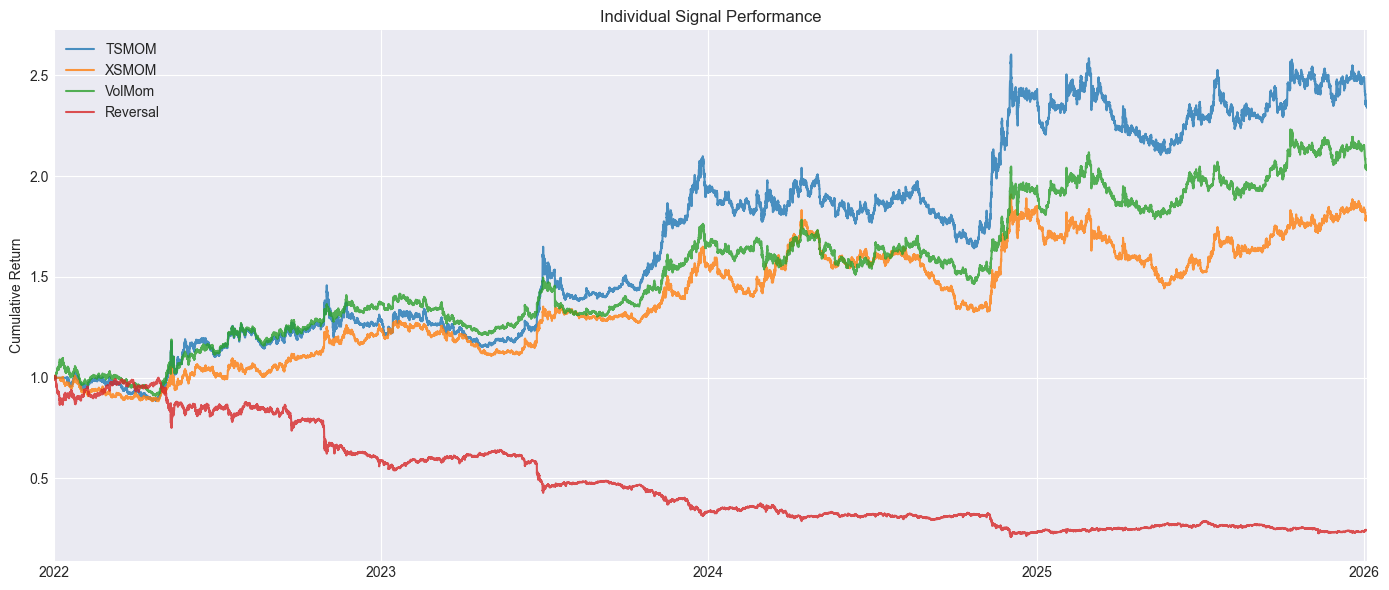

In [31]:
# equity curves for each signal
fig, ax = plt.subplots(figsize=(14, 6))

for sig, name in [(sig_tsmom_norm, 'TSMOM'), 
                   (sig_xsmom_norm, 'XSMOM'), 
                   (sig_volmom_norm, 'VolMom'),
                   (sig_reversal_norm, 'Reversal')]:
    bt = Backtester(ret, sig, tcost_bps=5)
    bt.run()
    eq = bt.get_equity_curve()
    eq.plot(ax=ax, label=name, alpha=0.8)

ax.set_title('Individual Signal Performance')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.tight_layout()


## Summary Stats Table


In [32]:
# final summary
strat_stats = get_stats(results['net_ret'])
btc_stats = get_stats(btc_ret.loc[results['net_ret'].index])

summary_raw = pd.DataFrame({
    'Stat Arb (Net)': strat_stats,
    'BTC Buy&Hold': btc_stats
})

# formatting nicely
summary = pd.DataFrame(index=summary_raw.index, columns=summary_raw.columns, dtype=object)
summary.loc['sharpe'] = summary_raw.loc['sharpe'].round(2)
summary.loc['sortino'] = summary_raw.loc['sortino'].round(2)
summary.loc['ann_ret'] = (summary_raw.loc['ann_ret'] * 100).round(1).astype(str) + '%'
summary.loc['ann_vol'] = (summary_raw.loc['ann_vol'] * 100).round(1).astype(str) + '%'
summary.loc['max_dd'] = (summary_raw.loc['max_dd'] * 100).round(1).astype(str) + '%'
summary.loc['total_ret'] = (summary_raw.loc['total_ret'] * 100).round(1).astype(str) + '%'


In [33]:
summary

,Stat Arb (Net),BTC Buy&Hold
sharpe,0.87,0.69
sortino,1.24,0.88
ann_ret,15.2%,35.4%
ann_vol,17.4%,51.0%
max_dd,-22.2%,-67.4%
total_ret,71.2%,141.3%


In [34]:
# additional metrics
print("Additional Metrics:")
print(f"\tAverage Turnover: {results['turnover'].mean():.2%}")
print(f"\tAnnualized Alpha: {alpha * 24 * 365 * 100:.2f}%")
print(f"\tMarket Beta: {beta:.3f}")
print(f"\tInformation Ratio: {ir:.2f}")


Additional Metrics:
	Average Turnover: 0.73%
	Annualized Alpha: 16.61%
	Market Beta: -0.040
	Information Ratio: 0.96
